In [1]:
import pandas as pd

Data Pipeline.

Schema Mapping using labels from readme.

In [2]:
# These names come from the NASA documentation
index_names = ['unit_nr', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = [f's_{i}' for i in range(1, 22)] 
col_names = index_names + setting_names + sensor_names

Data Ingestion.

In [3]:
# Path to your file based on your listdir result
train_path = '../data/train_FD001.txt'

# Load it, header is set to None as they are manually defined
df_train = pd.read_csv(train_path, sep='\s+', header=None, names=col_names)

# Look at the "Shape" and the first few rows. We use 0 to count number
# of rows and 1 to count number of columns to verify the data
print(f"Rows: {df_train.shape[0]}, Columns: {df_train.shape[1]}")

# Display a preview of the data
df_train.head()

Rows: 20631, Columns: 26


,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


Data Cleaning by dropping zero-variance features.

In [4]:
#Transpose the table so variables show as rows instead of columns
stats = df_train.describe().T

# Calculate how much each column varies
# A standard deviation of 0 means the sensor never changes
stats['std']

unit_nr        2.922763e+01
time_cycles    6.888099e+01
setting_1      2.187313e-03
setting_2      2.930621e-04
setting_3      0.000000e+00
s_1            6.537152e-11
s_2            5.000533e-01
s_3            6.131150e+00
s_4            9.000605e+00
s_5            3.394700e-12
s_6            1.388985e-03
s_7            8.850923e-01
s_8            7.098548e-02
s_9            2.208288e+01
s_10           4.660829e-13
s_11           2.670874e-01
s_12           7.375534e-01
s_13           7.191892e-02
s_14           1.907618e+01
s_15           3.750504e-02
s_16           1.556432e-14
s_17           1.548763e+00
s_18           0.000000e+00
s_19           0.000000e+00
s_20           1.807464e-01
s_21           1.082509e-01
Name: std, dtype: float64

In [5]:
# We identify the columns that show a standard deviation of 0
# to reduce dimensionality and prevent
dead_columns = stats[stats['std'] == 0].index.tolist()

print(f"Dropping these useless columns: {dead_columns}")

# 2. We drop them from our main DataFrame
df_train_cleaned = df_train.drop(columns=dead_columns)

# 3. Check the new shape
print(f"New Shape: {df_train_cleaned.shape}")

Dropping these useless columns: ['setting_3', 's_18', 's_19']
New Shape: (20631, 23)


Feature Engineering to derive the remaining useful life from run-to-failure sensor data.

In [6]:

# To find the maximum number of cycles for each engine we group by
# unit number and find the max value in time cycles, creating a list.
# We reset the index to make the label into a column so it can be manipulated
max_cycles = df_train_cleaned.groupby('unit_nr')['time_cycles'].max().reset_index()
max_cycles.columns = ['unit_nr', 'max_life']

max_cycles.head()

,unit_nr,max_life
0,1,192
1,2,287
2,3,179
3,4,189
4,5,269


In [7]:
# We left join the max cycles table onto the train table using the unit number
df_train_cleaned = df_train_cleaned.merge(max_cycles, on='unit_nr', how='left')

# Preview the merged table
# Now look at the first few rows to see the new column at the end
df_train_cleaned.head()

,unit_nr,time_cycles,setting_1,setting_2,s_1,s_2,s_3,s_4,s_5,s_6,...,s_11,s_12,s_13,s_14,s_15,s_16,s_17,s_20,s_21,max_life
0,1,1,-0.0007,-0.0004,518.67,641.82,1589.70,1400.60,14.62,21.61,...,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,39.06,23.4190,192
1,1,2,0.0019,-0.0003,518.67,642.15,1591.82,1403.14,14.62,21.61,...,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,39.00,23.4236,192
2,1,3,-0.0043,0.0003,518.67,642.35,1587.99,1404.20,14.62,21.61,...,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,38.95,23.3442,192
3,1,4,0.0007,0.0000,518.67,642.35,1582.79,1401.87,14.62,21.61,...,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,38.88,23.3739,192
4,1,5,-0.0019,-0.0002,518.67,642.37,1582.85,1406.22,14.62,21.61,...,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,38.90,23.4044,192


In [8]:
# We create the remaining useful life (RUL) column to show how
# many cycles are left. RUL = (max life) - (time cycles)
df_train_cleaned['RUL'] = df_train_cleaned['max_life'] - df_train_cleaned['time_cycles']

# Preview only the required columns to verify
df_train_cleaned[['unit_nr', 'time_cycles', 'max_life', 'RUL']].head()

,unit_nr,time_cycles,max_life,RUL
0,1,1,192,191
1,1,2,192,190
2,1,3,192,189
3,1,4,192,188
4,1,5,192,187


In [9]:
# Check the last rows of unit 1 to see the RUL reaches 0
df_train_cleaned[df_train_cleaned['unit_nr'] == 1].tail()


,unit_nr,time_cycles,setting_1,setting_2,s_1,s_2,s_3,s_4,s_5,s_6,...,s_12,s_13,s_14,s_15,s_16,s_17,s_20,s_21,max_life,RUL
187,1,188,-0.0067,0.0003,518.67,643.75,1602.38,1422.78,14.62,21.61,...,519.79,2388.23,8117.69,8.5207,0.03,396,38.51,22.9588,192,4
188,1,189,-0.0006,0.0002,518.67,644.18,1596.17,1428.01,14.62,21.61,...,519.58,2388.33,8117.51,8.5183,0.03,395,38.48,23.1127,192,3
189,1,190,-0.0027,0.0001,518.67,643.64,1599.22,1425.95,14.62,21.61,...,520.04,2388.35,8112.58,8.5223,0.03,398,38.49,23.0675,192,2
190,1,191,-0.0000,-0.0004,518.67,643.34,1602.36,1425.77,14.62,21.61,...,519.57,2388.30,8114.61,8.5174,0.03,394,38.45,23.1295,192,1
191,1,192,0.0009,-0.0000,518.67,643.54,1601.41,1427.20,14.62,21.61,...,520.08,2388.32,8110.93,8.5113,0.03,396,38.48,22.9649,192,0


In [10]:
# Now RUL is calculated we drop the max life column
df_train_cleaned = df_train_cleaned.drop(columns=['max_life'])

# Preview the cleaned table
df_train_cleaned.head()

,unit_nr,time_cycles,setting_1,setting_2,s_1,s_2,s_3,s_4,s_5,s_6,...,s_11,s_12,s_13,s_14,s_15,s_16,s_17,s_20,s_21,RUL
0,1,1,-0.0007,-0.0004,518.67,641.82,1589.70,1400.60,14.62,21.61,...,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,39.06,23.4190,191
1,1,2,0.0019,-0.0003,518.67,642.15,1591.82,1403.14,14.62,21.61,...,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,39.00,23.4236,190
2,1,3,-0.0043,0.0003,518.67,642.35,1587.99,1404.20,14.62,21.61,...,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,38.95,23.3442,189
3,1,4,0.0007,0.0000,518.67,642.35,1582.79,1401.87,14.62,21.61,...,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,518.67,642.37,1582.85,1406.22,14.62,21.61,...,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,38.90,23.4044,187


Data Preprocessing and Scaling. We scale all values from 0 to 1 to make sure all features are seen as equal importance.

In [11]:
from sklearn.preprocessing import MinMaxScaler

# 1. Initialize the Scaler
scaler = MinMaxScaler()

# Identify the columns to scale, we don't scale unit number, time cycles
# or remaining useful life, using difference to remove them from the list
cols_to_scale = df_train_cleaned.columns.difference(['unit_nr', 'time_cycles', 'RUL'])

# Fit and transform the remaining columns so they are scaled
df_train_cleaned[cols_to_scale] = scaler.fit_transform(df_train_cleaned[cols_to_scale])

# Preview the dataframe
df_train_cleaned.head()

,unit_nr,time_cycles,setting_1,setting_2,s_1,s_2,s_3,s_4,s_5,s_6,...,s_11,s_12,s_13,s_14,s_15,s_16,s_17,s_20,s_21,RUL
0,1,1,0.459770,0.166667,0.0,0.183735,0.406802,0.309757,0.0,1.0,...,0.369048,0.633262,0.205882,0.199608,0.363986,0.0,0.333333,0.713178,0.724662,191
1,1,2,0.609195,0.250000,0.0,0.283133,0.453019,0.352633,0.0,1.0,...,0.380952,0.765458,0.279412,0.162813,0.411312,0.0,0.333333,0.666667,0.731014,190
2,1,3,0.252874,0.750000,0.0,0.343373,0.369523,0.370527,0.0,1.0,...,0.250000,0.795309,0.220588,0.171793,0.357445,0.0,0.166667,0.627907,0.621375,189
3,1,4,0.540230,0.500000,0.0,0.343373,0.256159,0.331195,0.0,1.0,...,0.166667,0.889126,0.294118,0.174889,0.166603,0.0,0.333333,0.573643,0.662386,188
4,1,5,0.390805,0.333333,0.0,0.349398,0.257467,0.404625,0.0,1.0,...,0.255952,0.746269,0.235294,0.174734,0.402078,0.0,0.416667,0.589147,0.704502,187


Some of the scaled features are showing as 0. These features had very small standard deviation in initial tests. We check the stats of the scaled features to see which have been identified as non useful. These redundant features will be dropped to simplify the model and reduce computational noise.

In [12]:
# Look at the stats of your scaled sensors to identify redundant features
df_train_cleaned[cols_to_scale].describe().T[['min', 'max', 'mean', 'std']]

,min,max,mean,std
s_1,0.0,0.0,0.000000,0.000000
s_10,0.0,0.0,0.000000,0.000000
s_11,0.0,1.0,0.411410,0.158981
s_12,0.0,1.0,0.580697,0.157261
s_13,0.0,1.0,0.317871,0.105763
s_14,0.0,1.0,0.226095,0.098442
s_15,0.0,1.0,0.451118,0.144306
s_16,0.0,0.0,0.000000,0.000000
s_17,0.0,1.0,0.434221,0.129064
s_2,0.0,1.0,0.443052,0.150618


Identifying useful features. We programatically identify useful columns by checking the number of unique values in each feature. Any column with zero variance is considered not useful and simply increases dimensionality. This step ensures only sensors that capture engine degradation signals are used.

In [13]:
# Count columns that have more than one unique value
real_sensors = df_train_cleaned.columns[df_train_cleaned.nunique() > 1].tolist()

#Identify the names and number of useful columns
print(f"Number of useful columns: {len(real_sensors)}")
print(f"useful columns: {real_sensors}")

Number of useful columns: 20
useful columns: ['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 's_2', 's_3', 's_4', 's_6', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21', 'RUL']


In [14]:
# Update the dataframe to include only useful features
df_train_final = df_train_cleaned[real_sensors]

df_train_final.head()


,unit_nr,time_cycles,setting_1,setting_2,s_2,s_3,s_4,s_6,s_7,s_8,s_9,s_11,s_12,s_13,s_14,s_15,s_17,s_20,s_21,RUL
0,1,1,0.459770,0.166667,0.183735,0.406802,0.309757,1.0,0.726248,0.242424,0.109755,0.369048,0.633262,0.205882,0.199608,0.363986,0.333333,0.713178,0.724662,191
1,1,2,0.609195,0.250000,0.283133,0.453019,0.352633,1.0,0.628019,0.212121,0.100242,0.380952,0.765458,0.279412,0.162813,0.411312,0.333333,0.666667,0.731014,190
2,1,3,0.252874,0.750000,0.343373,0.369523,0.370527,1.0,0.710145,0.272727,0.140043,0.250000,0.795309,0.220588,0.171793,0.357445,0.166667,0.627907,0.621375,189
3,1,4,0.540230,0.500000,0.343373,0.256159,0.331195,1.0,0.740741,0.318182,0.124518,0.166667,0.889126,0.294118,0.174889,0.166603,0.333333,0.573643,0.662386,188
4,1,5,0.390805,0.333333,0.349398,0.257467,0.404625,1.0,0.668277,0.242424,0.149960,0.255952,0.746269,0.235294,0.174734,0.402078,0.416667,0.589147,0.704502,187


Data Splitting and Model Preparation.

In [15]:
# We now define X and y using the finalized dataframe
# We drop unit number because it is an ID and not a sensor
# We drop remaining useful life because it is the target
X = df_train_final.drop(columns=['unit_nr', 'RUL'])
y = df_train_final['RUL']

# Preview the final features
print(f"Final features: {X.columns.tolist()}")

Final features: ['time_cycles', 'setting_1', 'setting_2', 's_2', 's_3', 's_4', 's_6', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']


In [16]:
# We now split the data using train-test split
from sklearn.model_selection import train_test_split

# Split into 80% training and 20% testing using a fixed random state
# for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verify train-test split has completed successfully
print(f"X_train: {X_train.shape}, y_train: {y_train.shape} | X_test: {X_test.shape}, y_test: {y_test.shape}")

X_train: (16504, 18), y_train: (16504,) | X_test: (4127, 18), y_test: (4127,)


Model training and Evaluation. Now the data is cleaned, scaled and split, we train our first Machine Learning model to predict the remaining useful life.

Model 1: Linear Regression (Baseline)
We begin modelling using Linear Regression to establish a performance baseline. This model assumes a linear relationship between the sensor feature data and the remaining useful life.

The goal of this model is to determine how much of the engine's degradation can be explained by a simple linear trend before moving to more complex algorithms.

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Initialize and Train the model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [18]:
# Predict using the test set
y_pred = lr_model.predict(X_test)

Performance metrics.
Mean Absolute Error (MAE).
$$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$
Mean absolute error is the average of the absolute errors. You take all positive and negative errors, make them absolute (positive) and find their average. This method treats all errors equally, if the model if off by 10 cycles the penalty is 10, if it's off by 100, the penalty is 100. It is easy to explain to non technical stakeholders as it would be measured in cycles.

Mean Squared Error (MSE).
$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$
Mean squared error squares the errors. If the error is off by 2 the penalty is 4, if the error is off by 10 the penalty is 100. Squaring numbers makes them explode meaning the model is severely punished for big mistakes. It is more difficult to explain to non technical stakeholders as it is measured in cycles squared. MSE is a raw representation of a model's variance.

Root Mean Squared Error (RMSE).
$$RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$
Root mean squared error is the square root of the MSE. By taking the square root, we bring the units back down to cycles like with MAE. RMSE focuses on the model avoiding large errors.

In [19]:
# Calculate the Error
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Linear Regression MAE: {mae:.2f} cycles")
print(f"Linear Regression RMSE: {rmse:.2f} cycles")

Linear Regression MAE: 30.54 cycles
Linear Regression RMSE: 39.70 cycles


Linear Regression Model Visualization.
We visualize the model to show the performance.

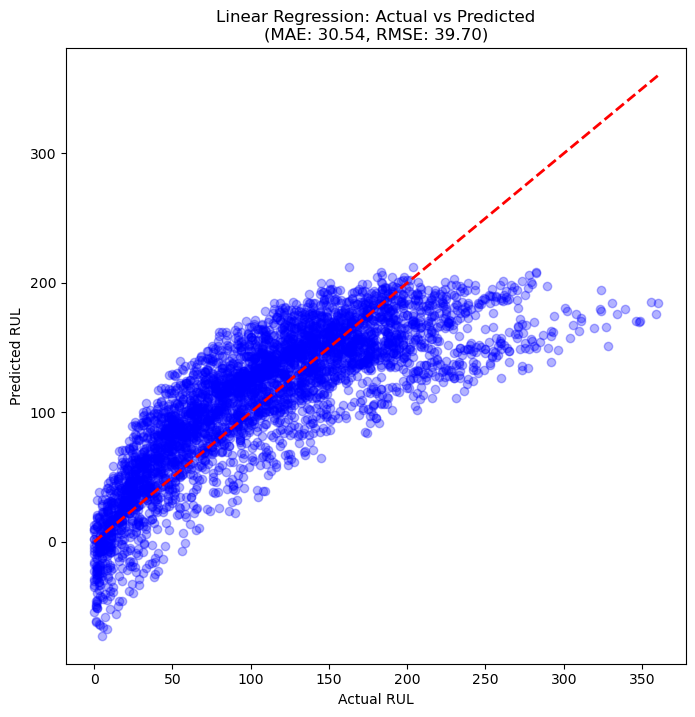

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual RUL')
plt.ylabel('Predicted RUL')
plt.title(f'Linear Regression: Actual vs Predicted\n(MAE: {mae:.2f}, RMSE: {rmse:.2f})')
plt.show()

Linear Regression Plot Analysis.
The Linear Regression plot reveals a non-linear arch in the data. This indicates a first-order linear assumption is insufficient for capturing the physics of engine wear. The model exhibits systematic bias, by significantly underestimating high RUL values where sensor signatures are relatively flat while at the same time committing boundary violations by predicting negative RUL values. Engine degradation follows an asymptotic path rather than a straight line, thus the linear fit fails to account for the acceleration of the curve near the end of life. A model with more architectural capacity, such as a Random Forest Regressor, is required to map such complex, non-linear sensor interations to the true degradation profile.

Model 2: Random Forest Regressor
Following the baseline model, we use a Random Forest Regressor. Unlike Linear Regression, Random Forest is a non-linear ensemble model, meaning it consists of multiple decision trees. This model captures complexity by modelling the non-linear curved degradation patterns we observed in the linear regression residuals. By averaging the predictions of 100 decision trees it reduces the risk of overfitting and is less sensitive to outliers. Finally it can identify complex relationships between multiple sensors.

The goal of this model is to improve our prediction accuracy by allowing the model to conform to the non linear nature of the engine data.

In [21]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the Forest (100 trees is the default) and Train the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [22]:
# Predict using the test set
y_pred_rf = rf_model.predict(X_test)

In [23]:
# Calculate the Error
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f"Random Forest MAE: {rf_mae:.2f}")
print(f"Random Forest RMSE: {rf_rmse:.2f}")


Random Forest MAE: 25.45
Random Forest RMSE: 35.93


Random Forest Model Visualization.
We visualize the model to show the performance.

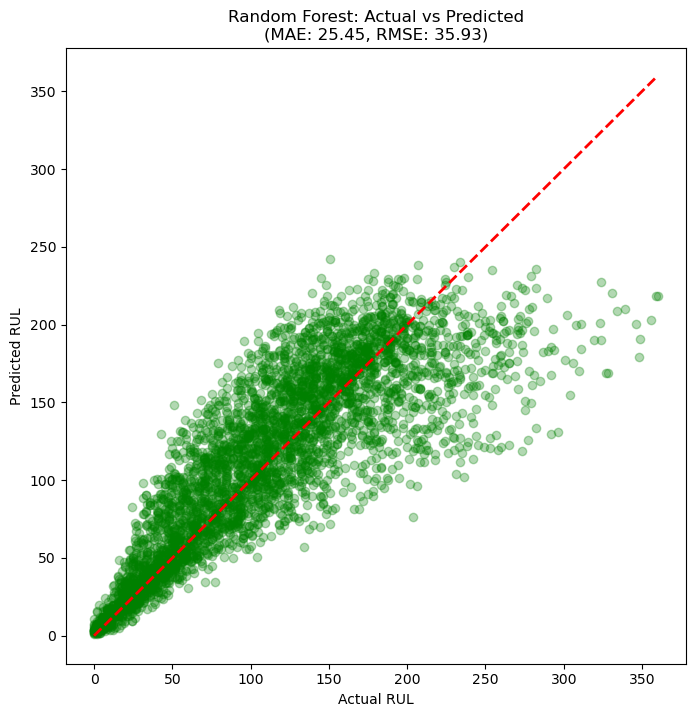

In [24]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_rf, alpha=0.3, color='green') # Using green for RF
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.xlabel('Actual RUL')
plt.ylabel('Predicted RUL')
plt.title(f'Random Forest: Actual vs Predicted\n(MAE: {rf_mae:.2f}, RMSE: {rf_rmse:.2f})')
plt.show()

Random Forest Plot Analysis.
The Random Forest scatter plot demonstrates a marked improvement in predictive accuracy, with the data points clustering significantly closer to the identity line than the linear baseline. The transition from a concave arch to a tighter, more linear distribution suggests that the ensemble's non linear decision boundaries successfully captured the accelerated degradation patterns in the sensor data. The model respects physical constraints by eliminating negative RUL predictions and shows it's highest precision in the critical near failure zone, where RUL is less than 50 cycles. While the model is still slightly pessimistic in early life stages, such as when the RUL is above 200 cycles, and exhibits a ceiling effect when the sensors haven't started changing, the overall reduction in MAE and RMSE confirms a higher capacity approach is better suited for the complex, non linear signals of predictive maintenance. 

Random Forest Feature Importance Analysis.
To move beyond black box predictions to explainable models, we examine feature importance. This allows us to identify which sensors are the primary drivers of degradation. Understanding the physical significance of these sensors helps to validate the model's logic and provides actionable insights for maintenance teams.

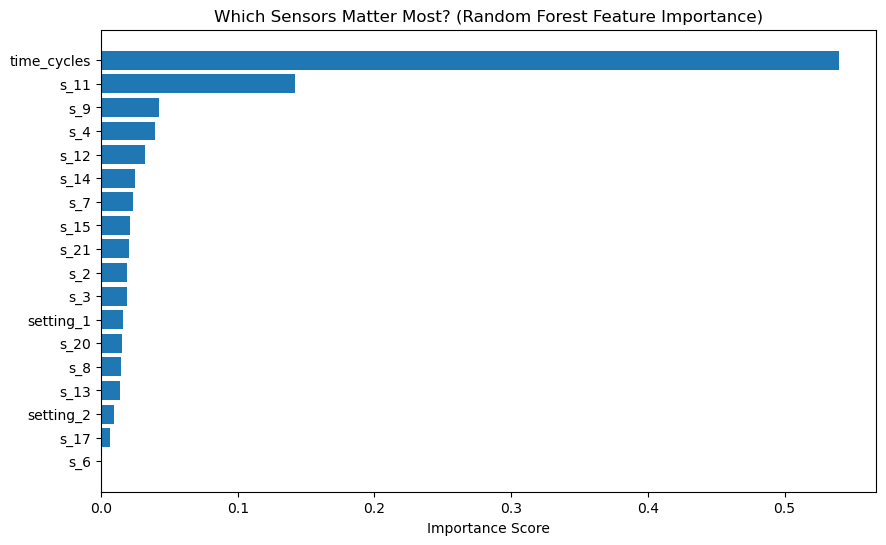

In [25]:
# Get importance levels from the model
importances = rf_model.feature_importances_
feature_names = X.columns

# Create a dataframe for easy plotting
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot it
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.gca().invert_yaxis()
plt.title('Which Sensors Matter Most? (Random Forest Feature Importance)')
plt.xlabel('Importance Score')
plt.show()

Reviewing the model